In [ ]:
# Importar librerias
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# semillas
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# generar datos sinteticos
dias = 365
t = np.linspace(0,2*np.pi, dias)
# print(t)

temperatura = 15 + 15 * np.sin(t) + np.random.normal(0,2,dias)
# print(temperatura)

# Normalizacion
temp_min = np.min(temperatura)
temp_max = np.max(temperatura)
temp_norm = (temperatura - temp_min) / (temp_max - temp_min)
# print(temp_norm)

In [ ]:
# Secuencias
window = 14 # 14 dias

def crear_sec(data, w):
  X, y = [], []
  for i in range(len(data)-w):
    X.append(data[i:i+w]) # ventana de 14 dias
    y.append(data[i+w]) # dia siguiente
  return np.array(X).reshape(-1,w,1), np.array(y)

In [ ]:
X, y = crear_sec(temp_norm, window)

In [ ]:
# Division de de datos 80% TRAIN y 20% TEST
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

print (X_train.shape)
# print (y_train.shape)
print (X_test.shape)
# print (y_test.shape)

(280, 14, 1)
(71, 14, 1)


In [ ]:
# Modelo LSTM
model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(128, input_shape=[window,1], return_sequences=True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(64, input_shape=[window,1], return_sequences=False),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(0.0001),
              loss='mse',
              metrics=['mae'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
    )

# Reducir el lr
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
    )

In [ ]:
# Entrenaminento
history = model.fit(
          X_train,
          y_train,
          epochs=200,
          batch_size=32,
          callbacks=[early_stopping, reduce_lr],
          validation_split=0.1,
          verbose=1
          )

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.4986 - mae: 0.6525 - val_loss: 0.0242 - val_mae: 0.1475 - learning_rate: 1.0000e-04
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3853 - mae: 0.5711 - val_loss: 0.0175 - val_mae: 0.1227 - learning_rate: 1.0000e-04
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2954 - mae: 0.4966 - val_loss: 0.0119 - val_mae: 0.0973 - learning_rate: 1.0000e-04
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2127 - mae: 0.4176 - val_loss: 0.0070 - val_mae: 0.0709 - learning_rate: 1.0000e-04
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1366 - mae: 0.3288 - val_loss: 0.0035 - val_mae: 0.0474 - learning_rate: 1.0000e-04
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0697 - mae: 0.2291 - val_loss: 0.0024 - val_mae: 0.0398 - learning_rate: 1.0000e-04
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0238 - mae: 0.1280 - val_loss: 0.0048 - val_mae: 0.0588 - learning_rate: 1.0

In [ ]:
#  Evaluacion
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

# desnormalizar
mae_C = test_mae*(temp_max - temp_min)
print(f'MAE: {mae_C:.4}')

loss_C = np.sqrt(test_loss)*(temp_max - temp_min)
print(f'MSE: {loss_C:.4}')
print(f'RMSE: {np.sqrt(test_loss):.4}')

print(f'La red se equivoca ~ {mae_C:.4} grados en promedio')

MAE: 3.29
MSE: 3.967
RMSE: 0.09899
La red se equivoca ~ 3.29 grados en promedio


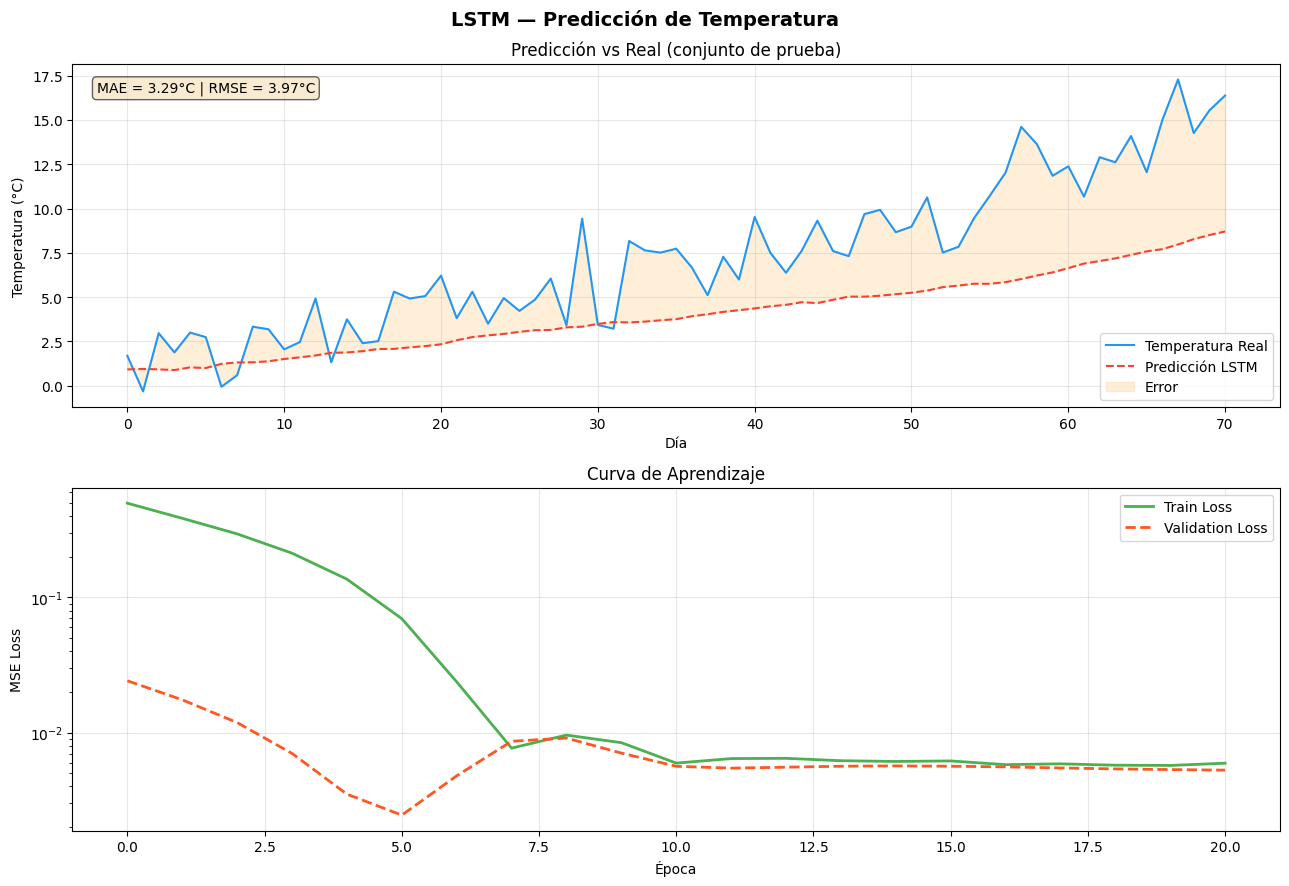

In [ ]:
# Predicciones en escala real (°C)
preds_norm = model.predict(X_test, verbose=0).flatten()
preds_C    = preds_norm * (temp_max - temp_min) + temp_min
real_C     = y_test     * (temp_max - temp_min) + temp_min

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.suptitle("LSTM — Predicción de Temperatura", fontsize=14, fontweight='bold')

# Gráfica 1: predicción vs real
ax1 = axes[0]
dias_test = np.arange(len(real_C))
ax1.plot(dias_test, real_C,  label="Temperatura Real",  color="#2196F3", lw=1.5)
ax1.plot(dias_test, preds_C, label="Predicción LSTM",   color="#F44336", lw=1.5, ls="--")
ax1.fill_between(dias_test, real_C, preds_C,            # área de error
                 alpha=0.15, color="#FF9800", label="Error")
ax1.set_title("Predicción vs Real (conjunto de prueba)")
ax1.set_xlabel("Día"); ax1.set_ylabel("Temperatura (°C)")
ax1.legend(); ax1.grid(alpha=0.3)
# Cuadro con métricas dentro del gráfico
ax1.text(0.02, 0.95, f"MAE = {mae_C:.2f}°C | RMSE = {loss_C:.2f}°C",
         transform=ax1.transAxes, fontsize=10, va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# Gráfica 2: curvas de pérdida train vs validación
ax2 = axes[1]
ax2.plot(history.history['loss'],     label="Train Loss",      color="#4CAF50", lw=2)
ax2.plot(history.history['val_loss'], label="Validation Loss", color="#FF5722", lw=2, ls="--")
ax2.set_title("Curva de Aprendizaje")
ax2.set_xlabel("Época"); ax2.set_ylabel("MSE Loss")
ax2.set_yscale('log')    # log para ver mejor la convergencia
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# **Pronostico del clima**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
import tensorflow as tf
import os

plt.style.use('ggplot')

In [ ]:
# Cargar dataset
zip_path = tf.keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname='jena_climate_2009_2016.csv.zip',
    extract=True)

extracted_dir = zip_path.replace('.zip', '')
csv_file_path = os.path.join(extracted_dir, 'jena_climate_2009_2016.csv')

df = pd.read_csv(csv_file_path)
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


| Index | Feature         | Format            | Description                                                                                     |
|-------|-----------------|-------------------|-----------------------------------------------------------------------------------------------|
| 1     | Date Time       | `01.01.2009 00:10:00` | Date-time reference                                                                            |
| 2     | p (mbar)        | `996.52`          | Atmospheric pressure in millibars                                                              |
| 3     | T (degC)        | `-8.02`           | Temperature in Celsius                                                                         |
| 4     | Tpot (K)        | `265.4`           | Temperature in Kelvin                                                                          |
| 5     | Tdew (degC)     | `-8.9`            | Dew point temperature in Celsius (absolute water content in air)                              |
| 6     | rh (%)          | `93.3`            | Relative humidity (%), indicating how saturated the air is with water vapor                   |
| 7     | VPmax (mbar)    | `3.33`            | Saturation vapor pressure (maximum vapor pressure at a given temperature)                     |
| 8     | VPact (mbar)    | `3.11`            | Actual vapor pressure                                                                         |
| 9     | VPdef (mbar)    | `0.22`            | Vapor pressure deficit (difference between saturation and actual vapor pressure)             |
| 10    | sh (g/kg)       | `1.94`            | Specific humidity (mass of water vapor per unit mass of air)                                  |
| 11    | H2OC (mmol/mol) | `3.12`            | Water vapor concentration (moles of water vapor per mole of air)                              |
| 12    | rho (g/m³)      | `1307.75`         | Air density                                                                                    |
| 13    | wv (m/s)        | `1.03`            | Wind speed                                                                                     |
| 14    | max. wv (m/s)   | `1.75`            | Maximum wind speed                                                                            |
| 15    | wd (deg)        | `152.3`           | Wind direction in degrees                                                                      |

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420551 non-null  object 
 1   p (mbar)         420551 non-null  float64
 2   T (degC)         420551 non-null  float64
 3   Tpot (K)         420551 non-null  float64
 4   Tdew (degC)      420551 non-null  float64
 5   rh (%)           420551 non-null  float64
 6   VPmax (mbar)     420551 non-null  float64
 7   VPact (mbar)     420551 non-null  float64
 8   VPdef (mbar)     420551 non-null  float64
 9   sh (g/kg)        420551 non-null  float64
 10  H2OC (mmol/mol)  420551 non-null  float64
 11  rho (g/m**3)     420551 non-null  float64
 12  wv (m/s)         420551 non-null  float64
 13  max. wv (m/s)    420551 non-null  float64
 14  wd (deg)         420551 non-null  float64
dtypes: float64(14), object(1)
memory usage: 48.1+ MB


In [ ]:
df.columns = df.columns.map(lambda x: x.replace(' ', '_').replace('.', ''))
cols = list(df.columns)
for col in cols:
    unique_count = df[col].nunique()
    most_common_value = df[col].mode().values[0]
    null_count = df[col].isnull().sum()
    print(f'- Columna {col} tiene {unique_count} valores unicos, valor mas comun: {most_common_value}, y {null_count} valores null')

- Columna Date_Time tiene 420224 valores unicos, valor mas comun: 01.07.2010 00:10:00, y 0 valores null
- Columna p_(mbar) tiene 6117 valores unicos, valor mas comun: 990.96, y 0 valores null
- Columna T_(degC) tiene 5530 valores unicos, valor mas comun: 8.13, y 0 valores null
- Columna Tpot_(K) tiene 5639 valores unicos, valor mas comun: 282.69, y 0 valores null
- Columna Tdew_(degC) tiene 4343 valores unicos, valor mas comun: 8.32, y 0 valores null
- Columna rh_(%) tiene 4805 valores unicos, valor mas comun: 100.0, y 0 valores null
- Columna VPmax_(mbar) tiene 3658 valores unicos, valor mas comun: 10.83, y 0 valores null
- Columna VPact_(mbar) tiene 2438 valores unicos, valor mas comun: 5.92, y 0 valores null
- Columna VPdef_(mbar) tiene 3649 valores unicos, valor mas comun: 0.0, y 0 valores null
- Columna sh_(g/kg) tiene 1600 valores unicos, valor mas comun: 3.79, y 0 valores null
- Columna H2OC_(mmol/mol) tiene 2483 valores unicos, valor mas comun: 6.08, y 0 valores null
- Columna 

In [ ]:
def date_features(df):
    df['date'] = pd.to_datetime(df['Date_Time'], format='%d.%m.%Y %H:%M:%S')
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['week'] = df['date'].dt.isocalendar().week
    df['quarter'] = df['date'].dt.quarter
    df['day_of_year'] = df['date'].dt.dayofyear
    df['day_of_week'] = df['date'].dt.dayofweek
    df['hour'] = df['date'].dt.hour
    df['minute'] = df['date'].dt.minute
    df['second'] = df['date'].dt.second
    df["month_sin"] = round(np.sin(2 * np.pi * df["month"] / 12), 2)
    df["month_cos"] = round(np.cos(2 * np.pi * df["month"] / 12), 2)
    df.drop('date', axis=1, inplace=True)
    return df

df = date_features(df)
df.head()

,Date_Time,p_(mbar),T_(degC),Tpot_(K),Tdew_(degC),rh_(%),VPmax_(mbar),VPact_(mbar),VPdef_(mbar),sh_(g/kg),...,month,week,quarter,day_of_year,day_of_week,hour,minute,second,month_sin,month_cos
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,...,1,1,1,1,3,0,10,0,0.5,0.87
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,...,1,1,1,1,3,0,20,0,0.5,0.87
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,...,1,1,1,1,3,0,30,0,0.5,0.87
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,...,1,1,1,1,3,0,40,0,0.5,0.87
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,...,1,1,1,1,3,0,50,0,0.5,0.87


/tmp/ipykernel_10958/1916298612.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


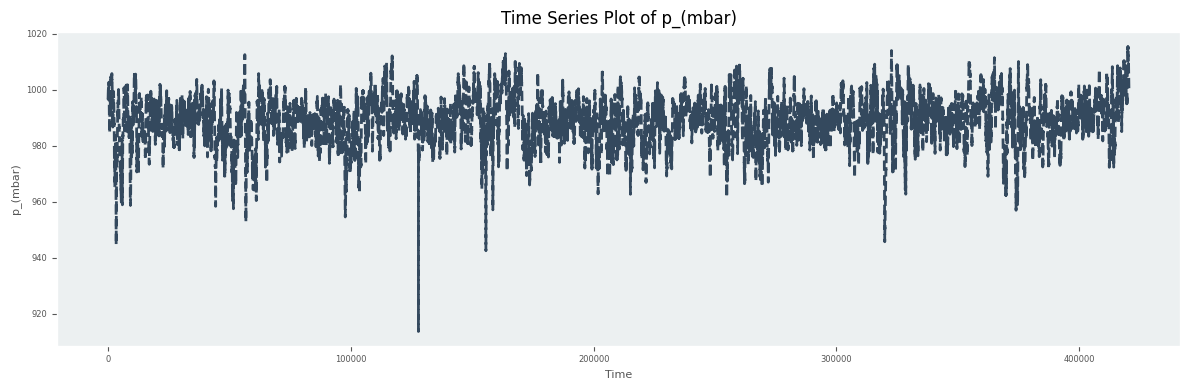

/tmp/ipykernel_10958/1916298612.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


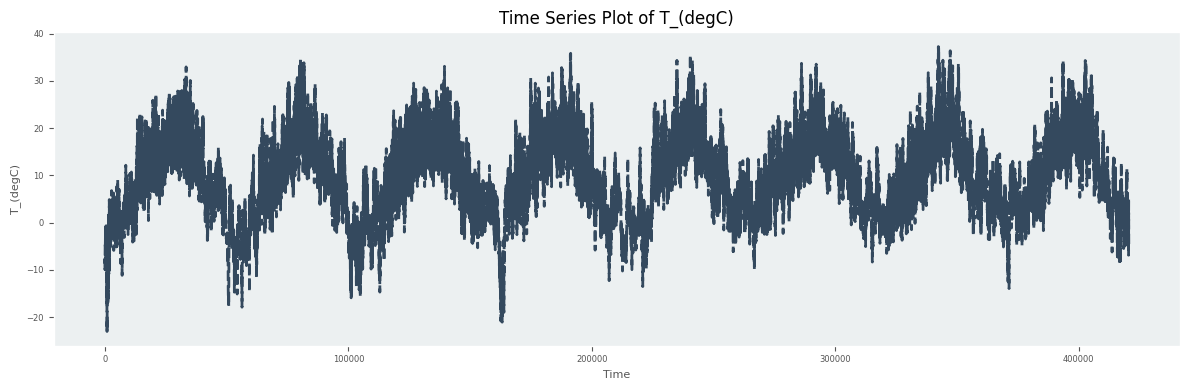

/tmp/ipykernel_10958/1916298612.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


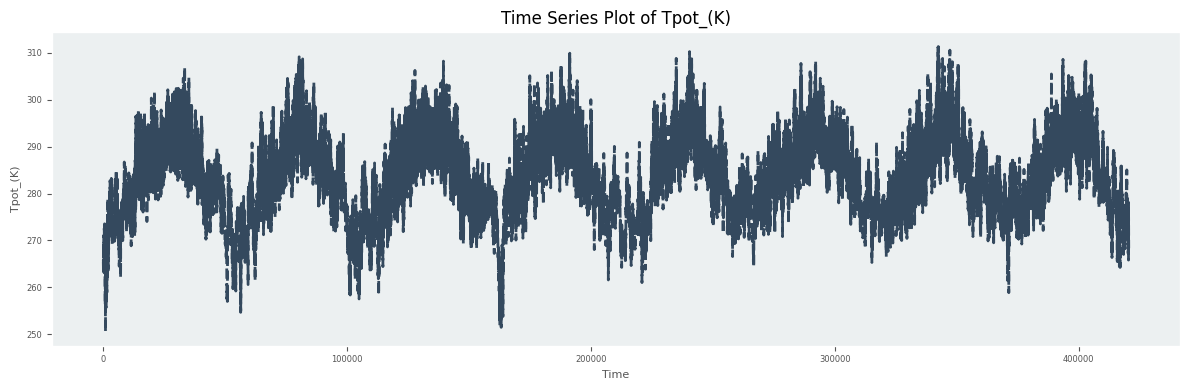

/tmp/ipykernel_10958/1916298612.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


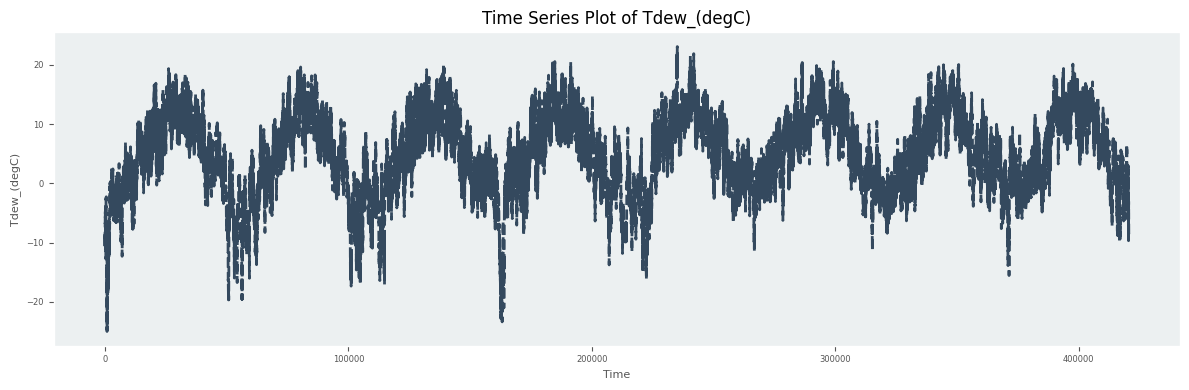

/tmp/ipykernel_10958/1916298612.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


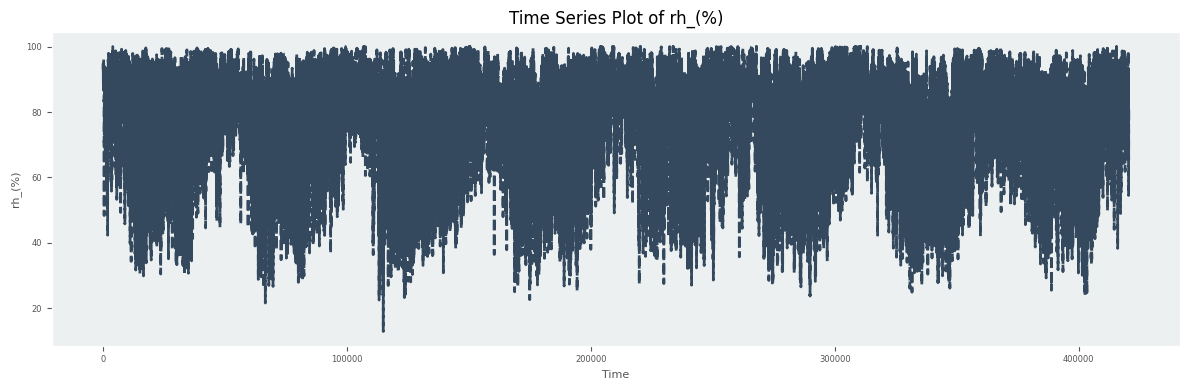

/tmp/ipykernel_10958/1916298612.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


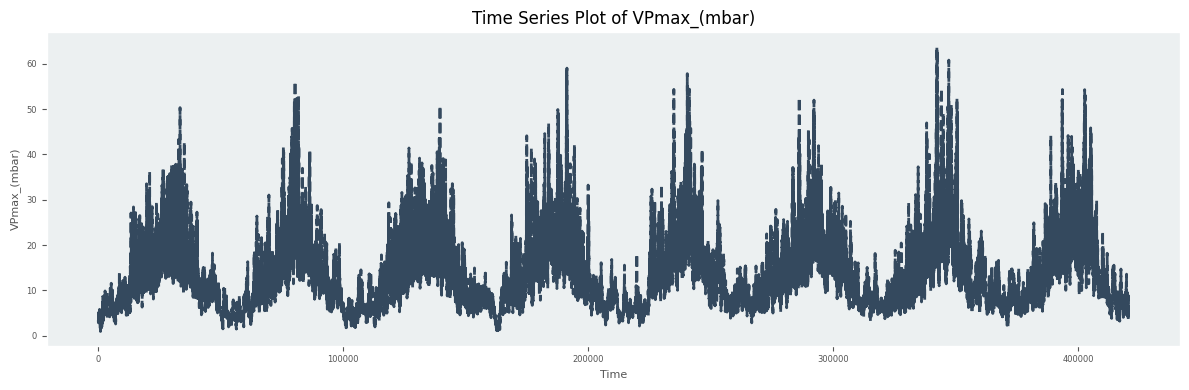

/tmp/ipykernel_10958/1916298612.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


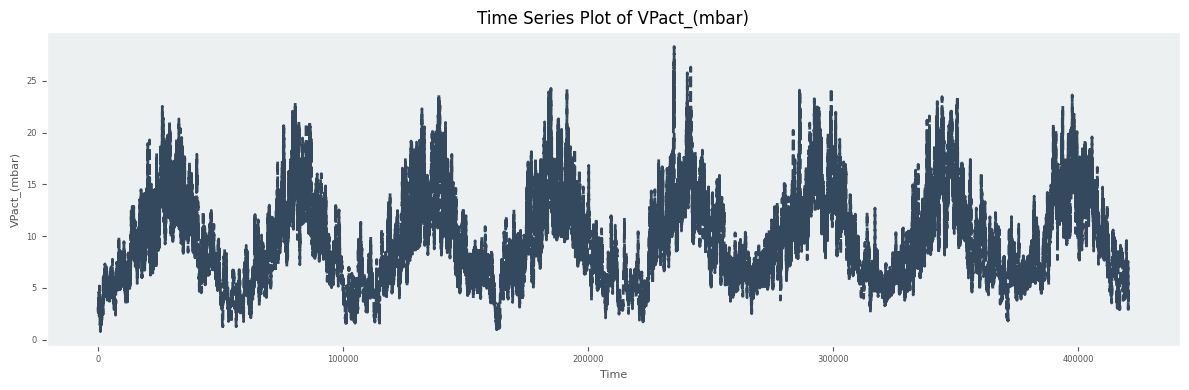

/tmp/ipykernel_10958/1916298612.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


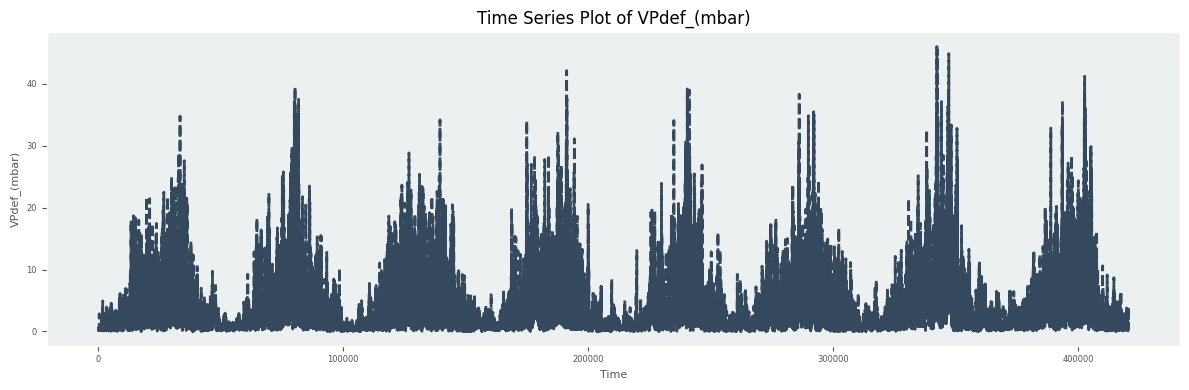

/tmp/ipykernel_10958/1916298612.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


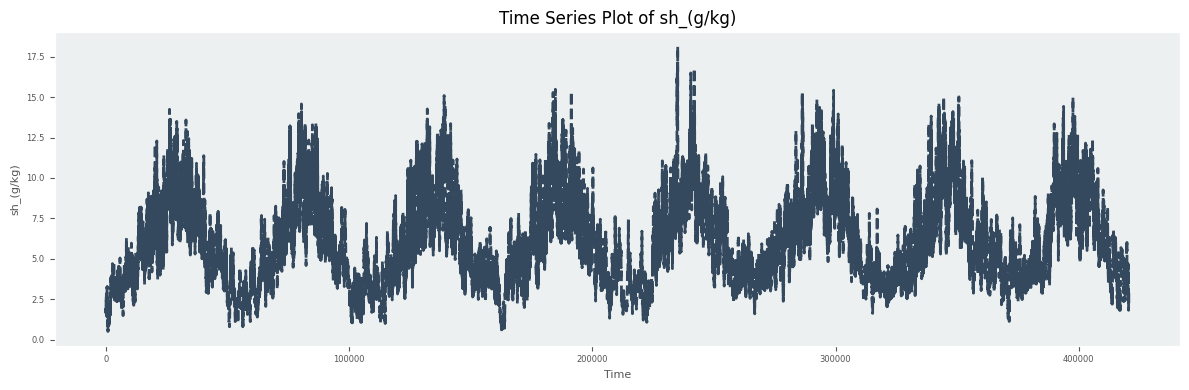

/tmp/ipykernel_10958/1916298612.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


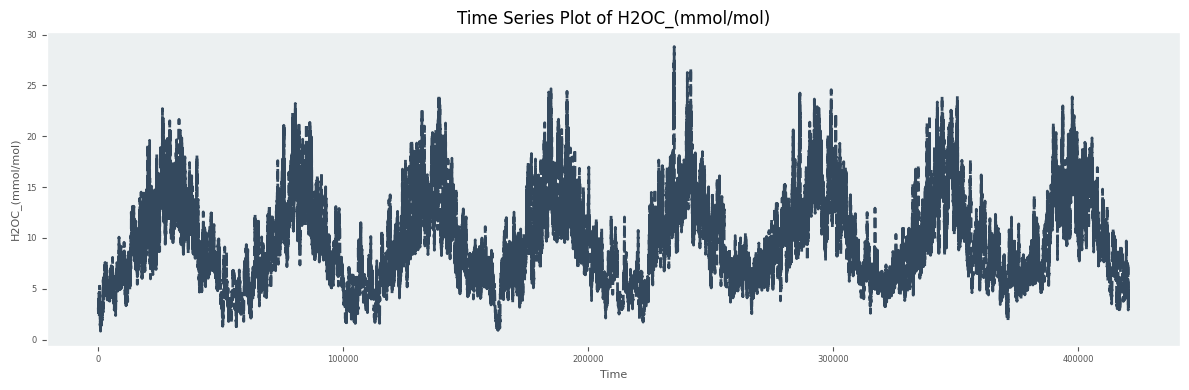

/tmp/ipykernel_10958/1916298612.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


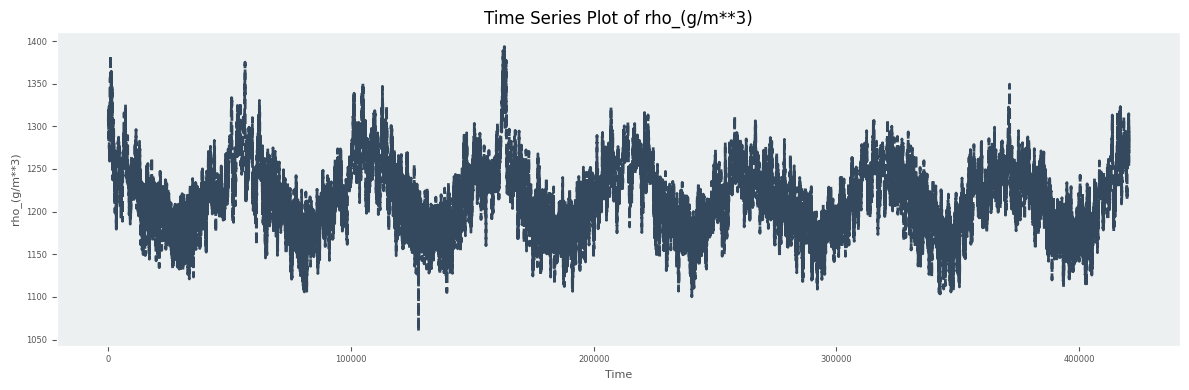

In [ ]:
cols = ['p_(mbar)', 'T_(degC)', 'Tpot_(K)', 'Tdew_(degC)', 'rh_(%)', 'VPmax_(mbar)', 'VPact_(mbar)', 'VPdef_(mbar)', 'sh_(g/kg)', 'H2OC_(mmol/mol)', 'rho_(g/m**3)']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col].fillna(df[col].mean(), inplace=True)
    df[col] = df[col].astype(float)

    plt.figure(figsize=(12, 4))
    df[col].plot(subplots=True, linestyle='dashed', color='#34495e', linewidth=2, markersize=12, markerfacecolor='#f1c40f')
    plt.title(f'Time Series Plot of {col}', fontsize=12)
    plt.xlabel('Time', fontsize=8)
    plt.ylabel(col, fontsize=8)
    plt.tick_params(axis='both', labelsize=6)
    plt.grid(False)
    plt.gca().set_facecolor('#ecf0f1')
    plt.tight_layout()
    plt.show()

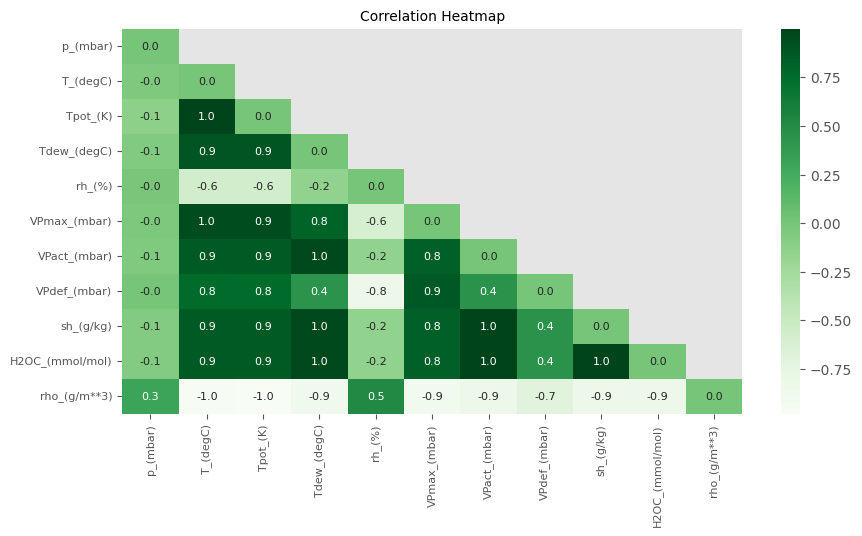

In [ ]:
numeric_df = df[cols].select_dtypes(include=['number'])
df_corr = numeric_df.corr()

plt.figure(figsize=(10, 5))
mask = np.triu(np.ones(df_corr.shape), k=1)
np.fill_diagonal(df_corr.values, 0)
sns.heatmap(data=df_corr, annot=True, annot_kws={"fontsize": 8}, fmt='.1f', cmap='Greens', mask=mask, cbar=True)
plt.title("Correlation Heatmap", fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.grid(False)
plt.show()
# hay una fuerte correlación entre las variables de presión y densidad del aire y la temperatura ambiente.

In [ ]:
from sklearn.preprocessing import StandardScaler

def train_val_test(df):
    train_split = int(len(df) * 0.7)
    validation_split = int(len(df) * 0.1)
    train_df = df[:train_split]
    validation_df = df[train_split: validation_split + train_split]
    test_df = df[validation_split + train_split:]
    return train_df, validation_df, test_df

train_df, validation_df, test_df = train_val_test(df)

def xy_splitter(train, validation, test):
    target = 'T_(degC)'
    # Drop 'Date_Time' and the target column from features
    X_train = train.drop(['Date_Time', target], axis=1)
    y_train = train[target].values # Convert to numpy array
    X_test = test.drop(['Date_Time', target], axis=1)
    y_test = test[target].values # Convert to numpy array
    X_val = validation.drop(['Date_Time', target], axis=1)
    y_val = validation[target].values # Convert to numpy array
    print(f'Train shape: X_train {X_train.shape} & y_train {y_train.shape}')
    print(f'Validation shape: X_val {X_val.shape} & y_val {y_val.shape}')
    print(f'Test shape: X_test {X_test.shape} & y_test {y_test.shape}')
    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = xy_splitter(train_processed, val_processed, test_processed)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Train shape: X_train (294385, 35) & y_train (294385,)
Validation shape: X_val (42055, 35) & y_val (42055,)
Test shape: X_test (84111, 35) & y_test (84111,)


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, target_col='T_(degC)'):
        self.target_col = target_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_new = X.copy()
        target = X_new[self.target_col]

        # Lag Features
        for days in [1, 7, 14]:
            X_new[f'{self.target_col}_lag_{days}d'] = target.shift(days * 144)

        # Rolling Features
        for days in [1, 7, 14]:
            window = days * 144
            X_new[f'{self.target_col}_rollmean_{days}d'] = target.rolling(window, min_periods=1).mean()
            X_new[f'{self.target_col}_rollstd_{days}d'] = target.rolling(window, min_periods=1).std()

        # Safe Percentage Change
        X_new[f'{self.target_col}_pct_change'] = target.pct_change().replace([np.inf, -np.inf], np.nan)

        # Wind Direction
        if 'wd_(deg)' in X.columns:
            wd_rad = np.deg2rad(X_new['wd_(deg)'])
            X_new['wd_sin'] = np.sin(wd_rad)
            X_new['wd_cos'] = np.cos(wd_rad)
            X_new = X_new.drop('wd_(deg)', axis=1)

        X_new = X_new.replace([np.inf, -np.inf], np.nan)
        X_new = X_new.fillna(method='ffill').fillna(method='bfill')
        return X_new

feature_engineer = FeatureEngineer()
train_processed = feature_engineer.fit_transform(train_df)
val_processed = feature_engineer.transform(validation_df)
test_processed = feature_engineer.transform(test_df)

/tmp/ipykernel_10958/3010280125.py:35: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_new = X_new.fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_10958/3010280125.py:35: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_new = X_new.fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_10958/3010280125.py:35: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_new = X_new.fillna(method='ffill').fillna(method='bfill')


In [ ]:
look_back = 14
batch_size = 64

train_gen = TimeseriesGenerator(data=X_train, targets=y_train, length=look_back, batch_size=batch_size, shuffle=False)
val_gen = TimeseriesGenerator(data=X_val, targets=y_val, length=look_back, batch_size=batch_size, shuffle=False)
test_gen = TimeseriesGenerator(data=X_test, targets=y_test, length=look_back, batch_size=batch_size, shuffle=False)

In [ ]:
# callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
    )

# Reducir el lr
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
    )

In [ ]:
# Modelo
n_features = X_train.shape[1] # numero de caracteristicas

model = Sequential()
model.add(LSTM(32, return_sequences=True, input_shape=(look_back, n_features)))
model.add(Dropout(0.2))
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer=tf.keras.optimizers.Adam(0.0001),
              loss='mse',
              metrics=['mae'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 14, 32)         │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,057 (66.63 KB)

 Trainable params: 17,057 (66.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(train_gen,
                    epochs=50,
                    validation_data=val_gen,
                    callbacks=[early_stopping, reduce_lr],
                    verbose=1
                    )

Epoch 1/50
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - loss: 42.2263 - mae: 4.5013 - val_loss: 5.4931 - val_mae: 1.5832 - learning_rate: 1.0000e-04
Epoch 2/50
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 36s 8ms/step - loss: 9.9718 - mae: 2.0198 - val_loss: 1.5850 - val_mae: 0.8943 - learning_rate: 1.0000e-04
Epoch 3/50
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 56s 12ms/step - loss: 4.4524 - mae: 1.3911 - val_loss: 0.5835 - val_mae: 0.5508 - learning_rate: 1.0000e-04
Epoch 4/50
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 35s 8ms/step - loss: 2.7568 - mae: 1.1483 - val_loss: 0.3416 - val_mae: 0.4261 - learning_rate: 1.0000e-04
Epoch 5/50
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 36s 8ms/step - loss: 2.0772 - mae: 1.0170 - val_loss: 0.2636 - val_mae: 0.3795 - learning_rate: 1.0000e-04
Epoch 6/50
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 37s 8ms/step - loss: 1.7672 - mae: 0.9431 - val_loss: 0.1687 - val_mae: 0.2941 - learning_rate: 1.0000e-04
Epoch 7/50
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 37s 8ms/step - loss: 1.6014 - mae: 0.8984 - val_loss: 0.1710 -

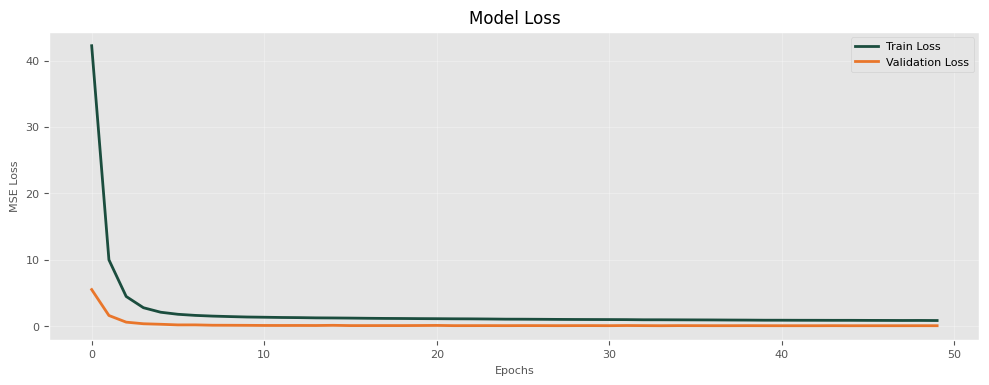

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label='Train Loss', color='#1B4D3E', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#E9762B', linewidth=2)
plt.title('Model Loss', fontsize=12)
plt.xlabel('Epochs', fontsize=8)
plt.ylabel('MSE Loss', fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

1315/1315 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


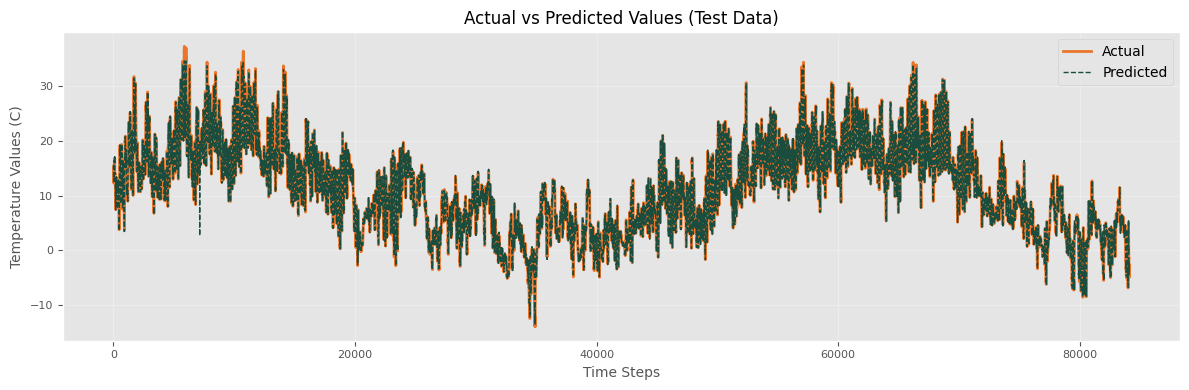

In [ ]:
# best_model = load_model('best_model.keras')
test_preds = model.predict(test_gen)

plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(y_test[look_back:])), y_test[look_back:], label='Actual', color='#E9762B', linewidth=2)
plt.plot(np.arange(len(test_preds)), test_preds, label='Predicted', color='#1B4D3E', linestyle='dashed', linewidth=1)
plt.title('Actual vs Predicted Values (Test Data)', fontsize=12)
plt.xlabel('Time Steps', fontsize=10)
plt.ylabel('Temperature Values (C)', fontsize=10)
plt.legend(fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()